In [3]:
# -*- coding: utf-8 -*-
"""
Created on Fri Feb 20 13:59:35 2026

@author: VictorVerbist
"""

#%%
import hub_optimisation.analysis_functions as af
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_csv('../results/nt_analysis.csv')

df['yield'] =  df[['yield_el_MWh_year','yield_h2_MWh_year']].max(axis=1)
df['yield_TWh'] = df['yield']/ 1e6 

df['infield_length_km'] =  df[['infield_horizontal_pipeline_length_m','infield_horizontal_cable_length_m']].max(axis=1) / 1e3

df['wake_loss_%'] = df['wake_loss_frac'] * 100

df = df.rename(columns={'total_LCOE':'LCOE'})

D = 'export_pipeline_diameter_inch'
P = 'compressor_outlet_pressure_bar'
nt = 'num_turbines'
S = 'stack_overplant_factor'
nep = 'num_export_pipelines'

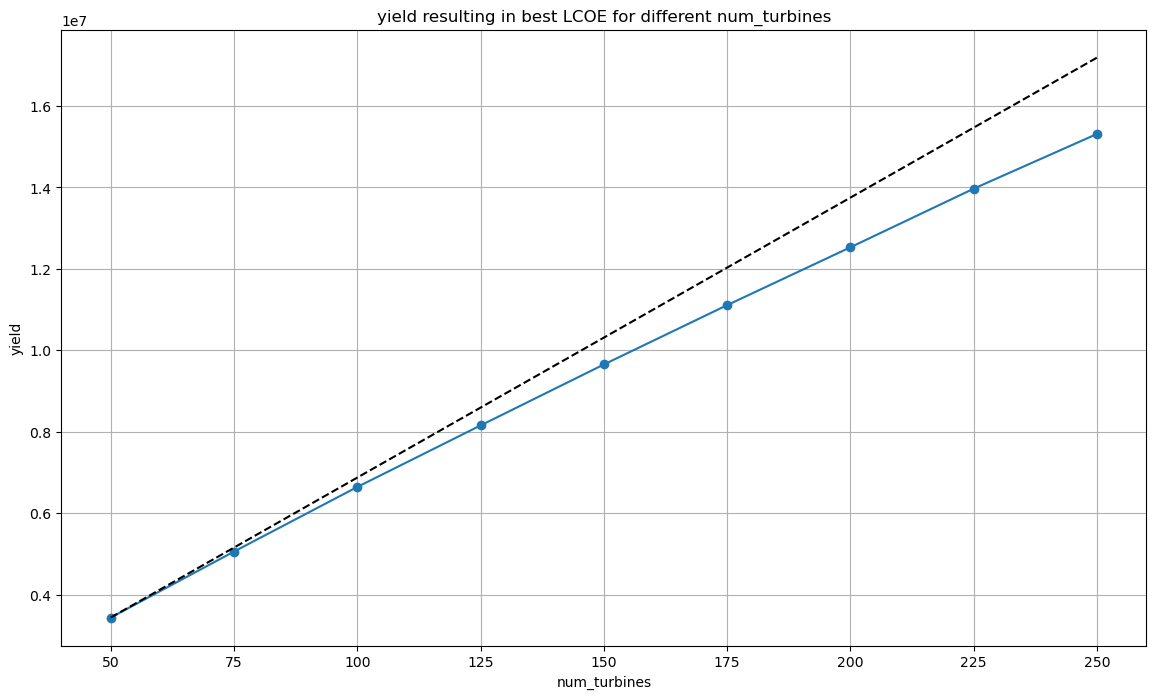

In [4]:
#%%
dfe  = df[ df['carrier']=='electricity']
dfhc = df[ df['carrier']=='hydrogen_central']
dfhd = df[ df['carrier']=='hydrogen_decentral']



x,y = af.plot_best_y_for_x( dfhd , 'num_turbines' , 'yield' , 'LCOE' , agg='min' )
plt.plot( x , y[0] * x/x[0]  , 'k--')

#%%

In [ ]:
plt.figure()

af.plot_best_y_for_x( dfhd , 'num_turbines' , 'wake_loss_%' , 'LCOE' , agg='min' )
plt.ylabel('Wake Losses [%]')
plt.title('Wake Losses as function of # turbines')


#%%

In [ ]:
df1 = df.copy()
carriers = df['carrier'].unique()
plt.figure(figsize=(24,8))
for i,c in enumerate(carriers):
    plt.subplot(1,3,i+1)
    df2 = df1[ df1['carrier']==c].fillna(0)
    df2 = af.fix_params(df2, {'farm_capacity_MW':1500})
    af.plot_stacked_costs(df2, 'num_turbines', value_key='LCOE', suffix='_cLCOE',new_fig=False)
    plt.title(c)
    plt.ylim([0,100])
    plt.ylabel('EUR/MWh')
    
#%%
x_key =  'num_turbines' # 'farm_area_km2'
carriers = df['carrier'].unique()
df1['yield'] =  df[['yield_el_MWh_year','yield_h2_MWh_year']].max(axis=1)
df1['yield_TWh'] = df1['yield']/ 1e6 
plt.figure(figsize=(18,6))
for i,c in enumerate(carriers):
    plt.subplot(1,3,i+1)
    df2 = df1[ df1['carrier']==c].fillna(0)
    x,y = af.plot_best_y_for_x( df2 , x_key , 'yield_TWh' , 'LCOE' , agg='min',new_fig=False )
    plt.plot( x , y[0] * x/x[0]  , 'k--')
    plt.ylim([0,20])
    plt.title(c)
    #af.plot_best_y_for_x( df2 , 'num_turbines' , 'wake_loss_frac' , 'total_LCOE' , agg='min' )
plt.tight_layout()

#%%

In [ ]:
carriers = df['carrier'].unique()
plt.figure()
for c in carriers:
    df1 = df[ df['carrier']==c]
    af.plot_best_y_for_x(df1, 'num_turbines','LCOE','LCOE',agg='min',new_fig=False)
plt.legend(carriers,title='carrier')
plt.ylim([0,100])

#%%

(array([ 50,  75, 100, 125, 150, 175, 200, 225, 250]),
 array([88.43396121, 84.1675753 , 82.42236631, 82.17906932, 87.80127672,
        87.2838222 , 87.17341075, 86.95992228, 87.33704212]))

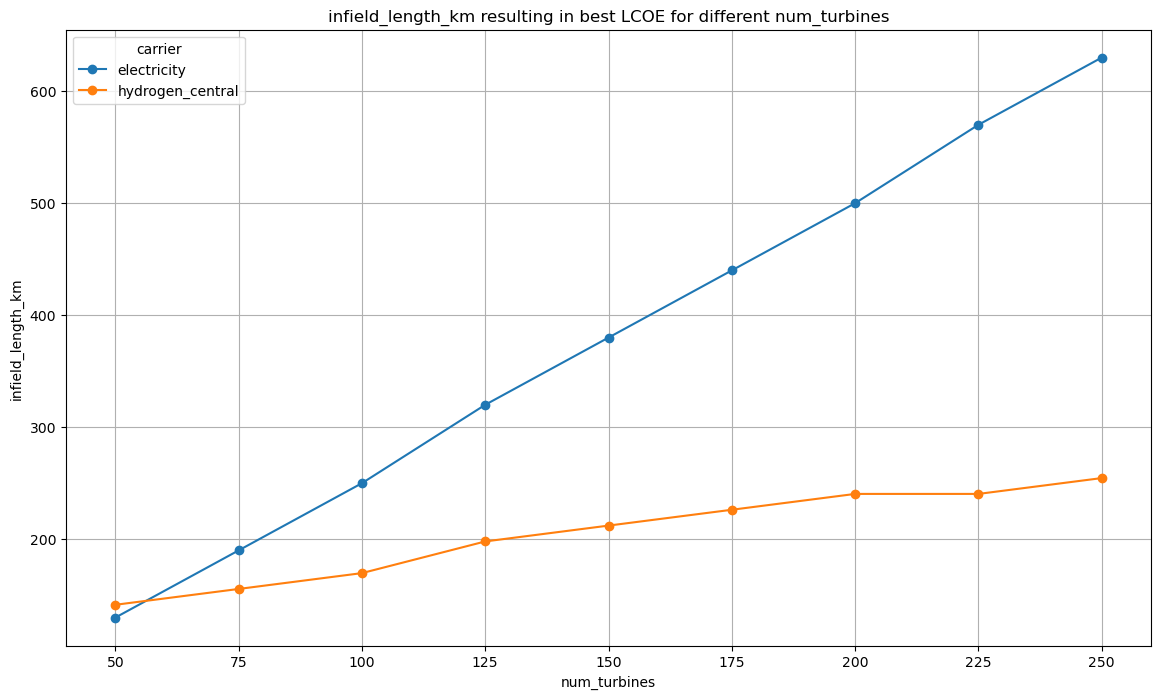

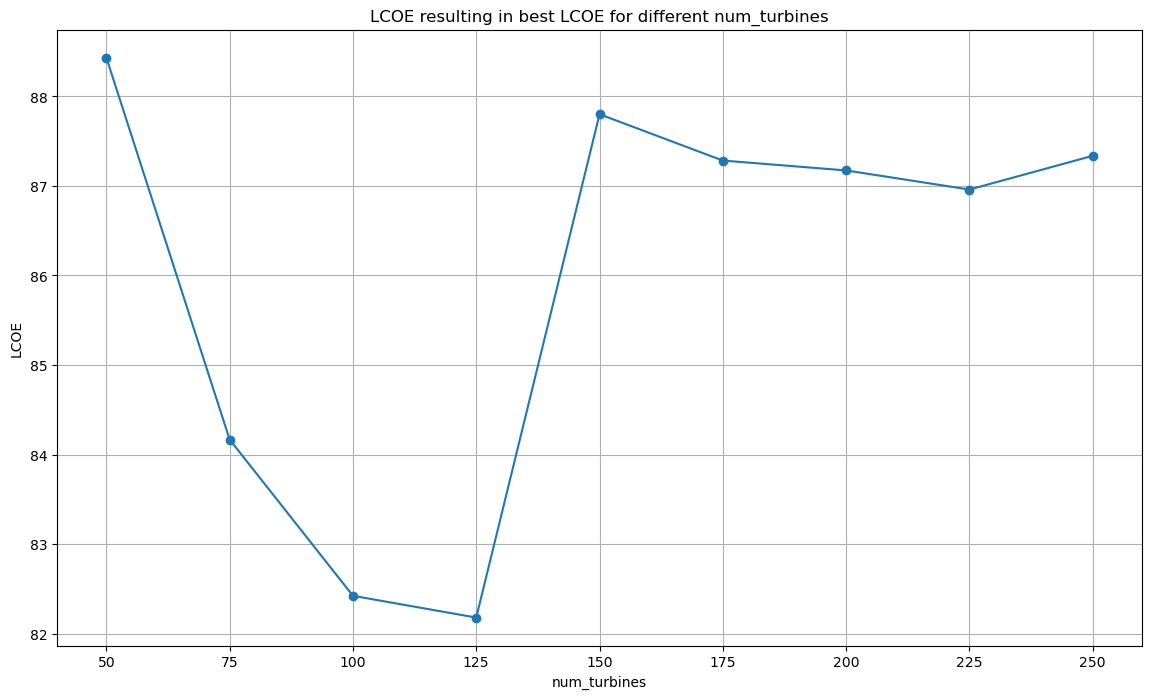

In [2]:
carriers = df['carrier'].unique()
plt.figure()
for c in carriers:
    if c == 'hydrogen_central' : continue
    df1 = df[ df['carrier']==c]
    af.plot_best_y_for_x(df1, 'num_turbines','infield_length_km','LCOE',agg='min',new_fig=False)
plt.legend(carriers,title='carrier')
#plt.ylim([0,100])

#%%

af.plot_best_y_for_x(dfe, nt, 'LCOE', 'LCOE')